# 03 - Similarity, Scaling and Distance Analysis

This notebook analyzes similarity and dissimilarity between Old School RuneScape players based on their cleaned Hiscores skill profiles.

The goal is to prepare the dataset for clustering by:

- creating a numeric feature matrix,
- scaling the attributes,
- calculating pairwise distances,
- identifying similar players,
- visualizing player profiles in two dimensions using PCA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

from scipy.spatial.distance import pdist, squareform

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
IMAGES_DIR = PROJECT_ROOT / "images"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROCESSED_DATA_DIR / "osrs_hiscores_cleaned.csv"

input_path

WindowsPath('C:/Projects/osrs-player-segmentation/data/processed/osrs_hiscores_cleaned.csv')

In [3]:
df = pd.read_csv(input_path)

df.head()

,player,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
0,Zezima,1466,76,76,75,1,1,1,1,80,...,45,1,33.000000,52.8,56.250,59.75,49.333333,99,1,31.568651
1,eszcape,2107,99,99,99,99,99,82,99,99,...,83,60,96.571429,76.8,86.375,89.00,87.791667,99,60,10.640281
2,Lynx Titan,2278,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166
3,Hey Jase,2278,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166
4,Woox,2340,99,99,99,99,99,99,99,99,...,99,63,99.000000,91.8,99.000,99.00,97.500000,99,63,7.348469


In [4]:
df.shape

(10, 34)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               10 non-null     object 
 1   overall              10 non-null     int64  
 2   attack               10 non-null     int64  
 3   defence              10 non-null     int64  
 4   strength             10 non-null     int64  
 5   hitpoints            10 non-null     int64  
 6   ranged               10 non-null     int64  
 7   prayer               10 non-null     int64  
 8   magic                10 non-null     int64  
 9   cooking              10 non-null     int64  
 10  woodcutting          10 non-null     int64  
 11  fletching            10 non-null     int64  
 12  fishing              10 non-null     int64  
 13  firemaking           10 non-null     int64  
 14  crafting             10 non-null     int64  
 15  smithing             10 non-null     int64 

## 2. Feature matrix

Clustering and distance-based methods require a numeric data matrix.

In this project:

- each row represents one OSRS player,
- each column represents a numeric skill-related attribute,
- the `player` column is used only as an identifier and is not included in the feature matrix.

In [7]:
feature_columns = [column for column in df.columns if column != "player"]

X = df[feature_columns].copy()

X.head()

,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,woodcutting,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
0,1466,76,76,75,1,1,1,1,80,78,...,45,1,33.000000,52.8,56.250,59.75,49.333333,99,1,31.568651
1,2107,99,99,99,99,99,82,99,99,81,...,83,60,96.571429,76.8,86.375,89.00,87.791667,99,60,10.640281
2,2278,99,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166
3,2278,99,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166
4,2340,99,99,99,99,99,99,99,99,99,...,99,63,99.000000,91.8,99.000,99.00,97.500000,99,63,7.348469


In [8]:
X.shape

(10, 33)

In [9]:
player_names = df["player"].values

player_names[:10]

array(['Zezima', 'eszcape', 'Lynx Titan', 'Hey Jase', 'Woox', 'B0aty',
       'Alkan', 'Settled', 'A Cold One', 'SoloMission'], dtype=object)

## 3. Scaling

Distance-based methods are sensitive to the scale of the input variables.

If one attribute has a larger numeric range than another, it can dominate the distance calculation.

In this notebook, two scaling methods are tested:

- StandardScaler: transforms variables to zero mean and unit variance,
- MinMaxScaler: transforms variables into the [0, 1] range.

In [10]:
standard_scaler = StandardScaler()
X_standard_scaled = standard_scaler.fit_transform(X)

X_standard_scaled[:5]

array([[-2.87441552, -3.        , -3.        , -3.        , -3.        ,
        -3.        , -2.95469752, -3.        , -3.        , -2.18424475,
        -2.57989397, -2.17565873,  0.33333333, -2.99938036, -2.80750709,
        -2.65495395, -2.90265529, -2.33486893, -2.75577669, -3.        ,
        -3.        , -2.7470113 , -2.85379824, -2.86991128, -1.11307812,
        -2.99797964, -2.34200634, -2.87153645, -2.90364464, -2.92780746,
         0.        , -1.11819134,  1.93997088],
       [-0.42525913,  0.33333333,  0.33333333,  0.33333333,  0.33333333,
         0.33333333, -0.18787094,  0.33333333,  0.33333333, -1.80104391,
        -1.23492555, -1.81102319, -3.        ,  0.27267094, -0.73881766,
        -1.09321633, -0.43080772, -1.53662314, -0.87208123,  0.33333333,
         0.33333333, -0.86469092, -0.58790693, -0.54955748,  0.31767589,
         0.22370821, -0.56439242, -0.54300252, -0.41844769, -0.24182566,
         0.        ,  0.33817266, -0.15873846],
       [ 0.22810396,  0.3333

In [11]:
minmax_scaler = MinMaxScaler()
X_minmax_scaled = minmax_scaler.fit_transform(X)

X_minmax_scaled[:5]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        ],
       [0.7043956 , 1.        , 1.        , 1.        , 1.        ,
        1.        , 0.82653061, 1.        , 1.        , 0.14285714,
        0.44      , 0.13636364, 0.        , 0.97959184, 0.63636364,
        0.5       , 0.74468085, 0.27586207, 0.58695652, 1.        ,
        1.        , 0.58181818, 0.68518519, 0.7037037 , 0.60204082,
        0.96320346, 0.51948052, 0.70467836, 0.74522293, 0.77432886,
        0.        , 0.60204082, 0.33705213],
       [0.89230769, 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.    

In [12]:
df_standard_scaled = pd.DataFrame(
    X_standard_scaled,
    columns=feature_columns,
    index=df["player"]
)

df_minmax_scaled = pd.DataFrame(
    X_minmax_scaled,
    columns=feature_columns,
    index=df["player"]
)

df_standard_scaled.head()

,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,woodcutting,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
player,,,,,,,,,,,,,,,,,,,,,
Zezima,-2.874416,-3.000000,-3.000000,-3.000000,-3.000000,-3.000000,-2.954698,-3.000000,-3.000000,-2.184245,...,-2.869911,-1.113078,-2.997980,-2.342006,-2.871536,-2.903645,-2.927807,0.0,-1.118191,1.939971
eszcape,-0.425259,0.333333,0.333333,0.333333,0.333333,0.333333,-0.187871,0.333333,0.333333,-1.801044,...,-0.549557,0.317676,0.223708,-0.564392,-0.543003,-0.418448,-0.241826,0.0,0.338173,-0.158738
Lynx Titan,0.228104,0.333333,0.333333,0.333333,0.333333,0.333333,0.392821,0.333333,0.333333,0.498161,...,0.427434,-1.113078,0.346784,-0.371818,0.432856,0.431192,0.255794,0.0,-1.118191,0.780278
Hey Jase,0.228104,0.333333,0.333333,0.333333,0.333333,0.333333,0.392821,0.333333,0.333333,0.498161,...,0.427434,-1.113078,0.346784,-0.371818,0.432856,0.431192,0.255794,0.0,-1.118191,0.780278
Woox,0.464996,0.333333,0.333333,0.333333,0.333333,0.333333,0.392821,0.333333,0.333333,0.498161,...,0.427434,0.390426,0.346784,0.546616,0.432856,0.431192,0.436217,0.0,0.412225,-0.488843


## 4. Pairwise distance calculation

In this section, we calculate pairwise distances between players.

A smaller distance means that two players have more similar skill profiles.

We calculate:

- Euclidean distance,
- Manhattan distance.

In [13]:
euclidean_distances = pairwise_distances(
    X_standard_scaled,
    metric="euclidean"
)

df_euclidean = pd.DataFrame(
    euclidean_distances,
    index=player_names,
    columns=player_names
)

df_euclidean.head()

,Zezima,eszcape,Lynx Titan,Hey Jase,Woox,B0aty,Alkan,Settled,A Cold One,SoloMission
Zezima,0.000000,14.476185,16.927991,16.927991,17.403555,17.858386,16.927991,17.224153,17.578570,17.858386
eszcape,14.476185,0.000000,6.857446,6.857446,6.623409,6.971065,6.857446,6.581282,6.647885,6.971065
Lynx Titan,16.927991,6.857446,0.000000,0.000000,2.673118,4.225251,0.000000,1.897051,4.103281,4.225251
Hey Jase,16.927991,6.857446,0.000000,0.000000,2.673118,4.225251,0.000000,1.897051,4.103281,4.225251
Woox,17.403555,6.623409,2.673118,2.673118,0.000000,1.552133,2.673118,0.776066,1.544550,1.552133


In [14]:
manhattan_distances = pairwise_distances(
    X_standard_scaled,
    metric="manhattan"
)

df_manhattan = pd.DataFrame(
    manhattan_distances,
    index=player_names,
    columns=player_names
)

df_manhattan.head()

,Zezima,eszcape,Lynx Titan,Hey Jase,Woox,B0aty,Alkan,Settled,A Cold One,SoloMission
Zezima,0.000000,76.651796,90.136950,90.136950,95.775741,99.049878,90.136950,94.138673,97.346403,99.049878
eszcape,76.651796,0.000000,27.804089,27.804089,25.790612,29.064749,27.804089,25.698269,27.361274,29.064749
Lynx Titan,90.136950,27.804089,0.000000,0.000000,5.638791,8.912927,0.000000,4.001722,9.713999,8.912927
Hey Jase,90.136950,27.804089,0.000000,0.000000,5.638791,8.912927,0.000000,4.001722,9.713999,8.912927
Woox,95.775741,25.790612,5.638791,5.638791,0.000000,3.274137,5.638791,1.637068,4.075209,3.274137


## 5. Find the most similar players

For each selected player, we can find the closest other players based on Euclidean distance.

This helps demonstrate how distance-based similarity works on OSRS player profiles.

In [15]:
def find_similar_players(player_name, distance_matrix, top_n=5):
    """
    Find the most similar players based on a given distance matrix.
    The selected player itself is removed from the result.
    """
    if player_name not in distance_matrix.index:
        raise ValueError(f"Player '{player_name}' not found in the dataset.")
    
    distances = distance_matrix.loc[player_name].sort_values()
    distances = distances.drop(player_name)
    
    return distances.head(top_n)

In [17]:
example_player = df["player"].iloc[0]

find_similar_players(example_player, df_euclidean, top_n=5)

eszcape       14.476185
Lynx Titan    16.927991
Hey Jase      16.927991
Alkan         16.927991
Settled       17.224153
Name: Zezima, dtype: float64

## 6. PCA visualization

The dataset contains many skill-related dimensions.

PCA is used to project the high-dimensional player profiles into two dimensions.

This makes it possible to visually inspect whether some players are naturally closer to each other.

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standard_scaled)

df_pca = pd.DataFrame({
    "player": df["player"],
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1]
})

df_pca.head()

,player,pca_1,pca_2
0,Zezima,15.111841,-0.586322
1,eszcape,1.847042,3.625659
2,Lynx Titan,-1.639530,-1.945135
3,Hey Jase,-1.639530,-1.945135
4,Woox,-2.279466,-0.013508


In [19]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.84085157, 0.09059087])

In [20]:
print(f"PCA component 1 explains {explained_variance[0]:.2%} of the variance.")
print(f"PCA component 2 explains {explained_variance[1]:.2%} of the variance.")
print(f"Together they explain {explained_variance.sum():.2%} of the variance.")

PCA component 1 explains 84.09% of the variance.
PCA component 2 explains 9.06% of the variance.
Together they explain 93.14% of the variance.


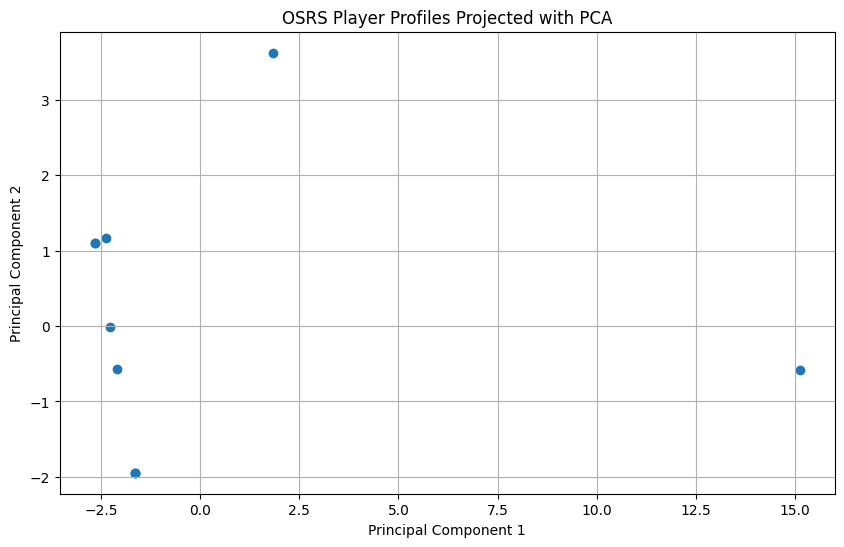

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df_pca["pca_1"], df_pca["pca_2"])

plt.title("OSRS Player Profiles Projected with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

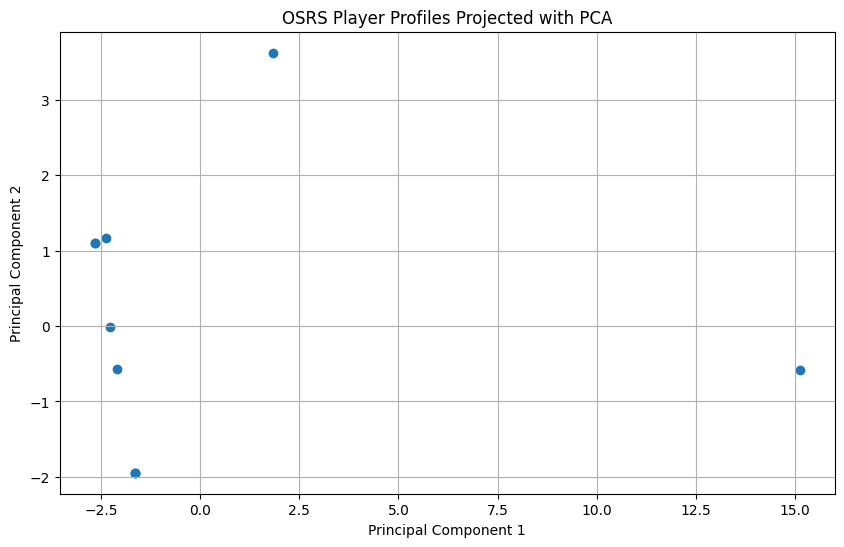

WindowsPath('C:/Projects/osrs-player-segmentation/images/pca_player_profiles.png')

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(df_pca["pca_1"], df_pca["pca_2"])

plt.title("OSRS Player Profiles Projected with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

pca_plot_path = IMAGES_DIR / "pca_player_profiles.png"
plt.savefig(pca_plot_path, dpi=300, bbox_inches="tight")

plt.show()

pca_plot_path

## 7. Save PCA dataset

The PCA-transformed dataset is saved for later visualization and clustering interpretation.

In [23]:
pca_output_path = PROCESSED_DATA_DIR / "osrs_hiscores_pca.csv"

df_pca.to_csv(pca_output_path, index=False, encoding="utf-8")

pca_output_path

WindowsPath('C:/Projects/osrs-player-segmentation/data/processed/osrs_hiscores_pca.csv')

## Summary

In this notebook, the cleaned OSRS Hiscores dataset was prepared for distance-based analysis.

The main steps were:

- creating a numeric feature matrix,
- scaling features with StandardScaler and MinMaxScaler,
- calculating Euclidean and Manhattan distance matrices,
- finding the most similar players based on distance,
- reducing the dataset to two dimensions using PCA,
- saving the PCA visualization.

The next notebook will use the scaled feature matrix for clustering analysis.